<a href="https://colab.research.google.com/github/bajon1/Deep-learning-lab/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install optuna statsmodels -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import optuna
from statsmodels.stats.contingency_tables import cochrans_q
import torch.nn.functional as F
from scipy import stats


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Lab 3: MLP – trening configuration

# Task 1: MLP implementation for MNIST

#### Goal: Build a multi-layer network to classify flattened MNIST images.

```python
# Load flattened MNIST images (vectors of dimension 784) from scikit-learn
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]
X = X.astype(np.float32) / 255.0 # scale to [0, 1]
y = y.astype(np.int64)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
```

1. Define an MLP with architecture: input=784 → hidden=1568 → hidden=1568 → output=10.
2. Use SGD optimiser, CrossEntropyLoss, and a learning rate of 0.01.
3. Split the trainval set into five folds using 5-fold cross-validation.
4. Train in mini-batches of 1024 images; each epoch consumes all training images. Set the model to model.train() mode during training.
5. After each training epoch, switch to model.eval() mode, run inference on the validation fold, and compute the mean validation loss. Whenever the validation loss reaches a new minimum, save a checkpoint containing: model state dict, optimiser state dict, epoch number, best validation loss, and the full list of training/validation losses across all completed epochs.
6. Plot validation and training loss as a function of epoch.
7. Train a separate model for each fold — the result is five independent models used in Task 2.

In [3]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [4]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]
X = X.astype(np.float32) / 255.0 # scale to [0, 1]
y = y.astype(np.int64)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

In [5]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(784, 1568),
        nn.ReLU(),
        nn.Linear(1568, 1568),
        nn.ReLU(),
        nn.Linear(1568, 10)
    )
  def forward(self, x):
    logits = self.layers(x)
    return logits

# alternative mlp without sequential

class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.input = nn.Linear(784, 1568)
    self.hidden = nn.Linear(1568, 1568)
    self.output = nn.Linear(1568, 10)

    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.input(x))
    x = self.relu(self.hidden(x))
    x = self.output(x)
    return x

In [7]:
lr = 1e-2
criterion = nn.CrossEntropyLoss()

In [6]:
splits = 5
kfold = KFold(n_splits=splits, shuffle = True)

X_trainval =  torch.tensor(X_trainval, dtype = torch.float32)
y_trainval = torch.tensor(y_trainval, dtype = torch.long)
X_test =  torch.tensor(X_test, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.long).to(device)

In [27]:
EPOCHS = 100
fold_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):

  best_val_loss = np.inf
  train_losses = []
  val_losses = []

  X_train, y_train = X_trainval[train_idx], y_trainval[train_idx]
  X_val, y_val = X_trainval[val_idx].to(device), y_trainval[val_idx].to(device)

  model = MLP().to(device)
  optim = torch.optim.SGD(model.parameters(), lr=lr)

  train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True, pin_memory=True)

  for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

      optim.zero_grad()
      loss = criterion(model(X_batch), y_batch)
      loss.backward()
      optim.step()
      train_loss += loss.item() * len(X_batch)

    train_losses.append(train_loss / len(X_train))

    model.eval()
    with torch.no_grad():
      val_loss = criterion(model(X_val), y_val).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      checkpoint = {
          'model_state': model.state_dict(),
          'optim_state': optim.state_dict(),
          'epoch': epoch,
          'best_val_loss': best_val_loss,
          'train_losses': train_losses.copy(),
          'val_losses': val_losses.copy()
      }

  torch.cuda.empty_cache()
  del model, optim, X_train, y_train, X_val, y_val

  fold_models.append(checkpoint)
  print(f"Fold {fold+1}/5 — best val loss: {best_val_loss:.4f}")

/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Fold 1/5 — best val loss: 0.2625
Fold 2/5 — best val loss: 0.2640
Fold 3/5 — best val loss: 0.2687
Fold 4/5 — best val loss: 0.2770
Fold 5/5 — best val loss: 0.2839


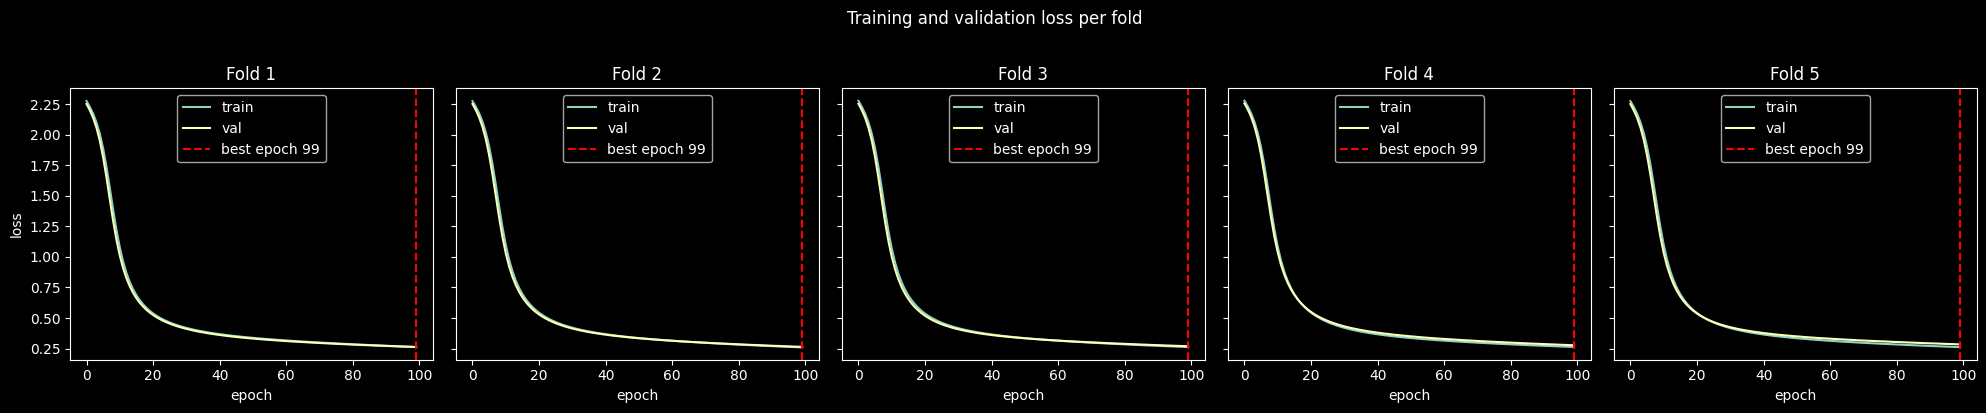

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for fold, checkpoint in enumerate(fold_models):
    ax = axes[fold]
    ax.plot(checkpoint['train_losses'], label='train')
    ax.plot(checkpoint['val_losses'],   label='val')
    ax.axvline(checkpoint['epoch'], color='red', linestyle='--', label=f"best epoch {checkpoint['epoch']}")
    ax.set_title(f'Fold {fold+1}')
    ax.set_xlabel('epoch')
    if fold == 0:
        ax.set_ylabel('loss')
    ax.legend()

plt.suptitle('Training and validation loss per fold', y=1.02)
plt.tight_layout()
plt.show()

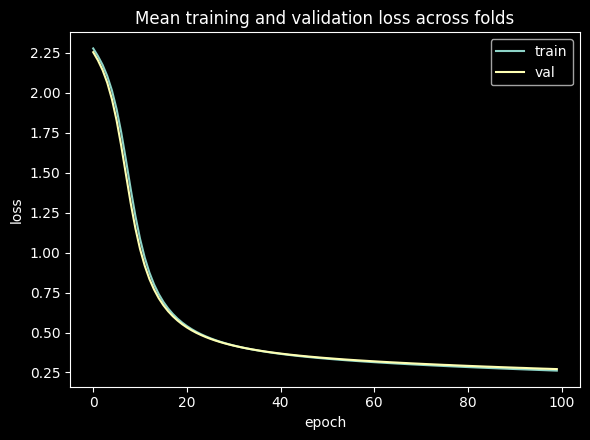

In [29]:
min_epochs = min(len(cp['train_losses']) for cp in fold_models)

mean_train = np.mean([cp['train_losses'][:min_epochs] for cp in fold_models], axis=0)
mean_val   = np.mean([cp['val_losses'][:min_epochs]   for cp in fold_models], axis=0)

plt.figure(figsize=(6, 4.5))
plt.plot(mean_train, label='train')
plt.plot(mean_val,   label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Mean training and validation loss across folds')
plt.legend()
plt.tight_layout()
plt.show()

# Task 2: Inference and prediction uncertainty

#### Goal: Evaluate prediction uncertainty using ensemble methods.

1. Majority voting — run all five models, obtain the argmax class from each, and return the class chosen by the majority.
2. Mean response — run all five models, average the softmax probabilities across models, and return the argmax of the averaged distribution.
3. Use Shannon entropy to estimate prediction uncertainty for both ensemble variants. How does entropy differ between confident and uncertain predictions?
4. Report test-set accuracy for both variants.
5. Use Cochran's Q test to determine whether the accuracy difference between the two methods is statistically significant.

In [30]:
def majority_voting(models, X, y):

  preds = []

  for model in models:
    with torch.no_grad():
      model.eval()
      logits = model(X)

      pred_list = F.softmax(logits, dim=1).argmax(dim=1) #argmax(logits, dim=1) does the same
      preds.append(pred_list)

  preds = torch.stack(preds, dim=0).cpu().numpy()

  probs = np.zeros((len(y), 10))
  for i in range(10):
    probs[:, i] = (preds == i).sum(axis=0) / len(models)

  final_preds = stats.mode(preds, axis=0, keepdims=True).mode.flatten()

  accuracy = (final_preds == y.cpu().numpy()).mean()
  entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1).mean()

  print("Predictions:", final_preds, "\nAccuracy: ", accuracy, "\nShannon entropy", entropy)

  return final_preds

In [31]:
def mean_response(models, X, y):
  probs = []

  for model in models:
    with torch.no_grad():
      model.eval()
      logits = model(X)

      prob = F.softmax(logits, dim=1)
      probs.append(prob.cpu().numpy())

  probs = np.stack(probs, axis=0)
  mean_probs = probs.mean(axis=0)
  final_preds = mean_probs.argmax(axis=1)

  accuracy = (final_preds == y.cpu().numpy()).mean()
  entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-9), axis=1).mean()

  print("Predictions:", final_preds, "\nAccuracy: ", accuracy, "\nShannon entropy", entropy)

  return final_preds

In [32]:
models = []

for checkpoint in fold_models:
  model = MLP().to(device)
  model.load_state_dict(checkpoint['model_state'])

  models.append(model)

print("Majority voting ensemble: ")
mv_preds = majority_voting(models, X_test, y_test)

print("\nMean response ensemble: ")
mr_preds = mean_response(models, X_test, y_test)

y_np = y_test.cpu().numpy()

binary_matrix = np.stack([(mv_preds == y_np).astype(int), (mr_preds == y_np).astype(int)], axis=1)
print("\nCochrans q test metrics:", cochrans_q(binary_matrix))

Majority voting ensemble: 
Predictions: [7 4 5 ... 6 4 3] 
Accuracy:  0.9222 
Shannon entropy 0.015344413527851798

Mean response ensemble: 
Predictions: [7 4 5 ... 6 4 3] 
Accuracy:  0.922 
Shannon entropy 0.33153555

Cochrans q test metrics: df          1
pvalue      0.6547208460185768
statistic   0.2


# Task 3: Learning rate selection

#### Goal: Find an optimal learning rate using automated hyperparameter search.

1. Implement an objective_lr function for Optuna that trains the network for a small number of epochs and returns the mean 5-fold cross-validation loss on the validation set.
2. Run the Optuna study to find the optimal learning rate.
3. Retrain the full model using the optimal learning rate found, following the same procedure as Task 1.
4. Compare loss curves between the fixed LR from Task 1 and the Optuna-optimised LR using a side-by-side plot.

In [8]:
def objective_lr(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    fold_losses = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):
        X_train = X_trainval[train_idx]
        y_train = y_trainval[train_idx]
        X_val = X_trainval[val_idx].to(device)
        y_val = y_trainval[val_idx].to(device)

        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True, pin_memory=True)

        model = MLP().to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)

        for epoch in range(5):
            model.train()
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                optimizer.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            fold_loss = criterion(model(X_val), y_val).item()
        fold_losses.append(fold_loss)

    return np.mean(fold_losses)

study = optuna.create_study(direction='minimize')
study.optimize(objective_lr, n_trials=20)

best_lr = study.best_params['lr']
print(f"Best learning rate: {best_lr:.6f}")
print(f"Best kfold mean loss: {study.best_value:.4f}")

[I 2026-05-21 15:08:31,423] A new study created in memory with name: no-name-badab770-fbed-4c7c-960f-8e636f925f6a
/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[I 2026-05-21 15:08:42,596] Trial 0 finished with value: 2.30263204574585 and parameters: {'lr': 4.190588327163765e-05}. Best is trial 0 with value: 2.30263204574585.
[I 2026-05-21 15:08:52,202] Trial 1 finished with value: 2.254883575439453 and parameters: {'lr': 0.0022327193985219097}. Best is trial 1 with value: 2.254883575439453.
[I 2026-05-21 15:09:01,901] Trial 2 finished with value: 2.3038408279418947 and parameters: {'lr': 2.9327505129674615e-05}. Best is trial 1 with value: 2.254883575439453.
[I 2026-05-21 15:09:11,617] Trial 3 finished with value: 1.0007969737052917 and parameters: {'lr': 0.02278379268

Best learning rate: 0.098773
Best kfold mean loss: 0.3489


In [9]:
def objective_sgd(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    momentum = trial.suggest_float('momentum', 0.0, 0.99)
    nesterov = trial.suggest_categorical('nesterov', [True, False])
    if nesterov and momentum == 0.0:
        momentum = 0.01

    sgd_fold_losses = []
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):
        X_train = X_trainval[train_idx]
        y_train = y_trainval[train_idx]
        X_val   = X_trainval[val_idx].to(device)
        y_val   = y_trainval[val_idx].to(device)
        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True, pin_memory=True)

        model = MLP().to(device)
        optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=nesterov)

        for epoch in range(5):
            model.train()
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                optim.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optim.step()

        model.eval()
        with torch.no_grad():
            sgd_fold_losses.append(criterion(model(X_val), y_val).item())

        del model, optim
        torch.cuda.empty_cache()

    return np.mean(sgd_fold_losses)


sgd_study = optuna.create_study(direction='minimize')
sgd_study.optimize(objective_sgd, n_trials=20)

best_sgd_lr = sgd_study.best_params['lr']
best_sgd_momentum = sgd_study.best_params['momentum']
best_sgd_nesterov = sgd_study.best_params['nesterov']
print(f"Best SGD lr: {best_sgd_lr:.4f}")
print(f"Best SGD momentum: {best_sgd_momentum:.4f}")
print(f"Best SGD nesterov: {best_sgd_nesterov}")
print(f"Best SGD val loss: {sgd_study.best_value:.4f}")

[I 2026-05-21 15:11:53,367] A new study created in memory with name: no-name-079c0c19-2f31-4f4c-aeb9-578d1aaefe3a
[I 2026-05-21 15:12:03,552] Trial 0 finished with value: 2.259742784500122 and parameters: {'lr': 0.000924161856711229, 'momentum': 0.5192159059672729, 'nesterov': False}. Best is trial 0 with value: 2.259742784500122.
[I 2026-05-21 15:12:13,782] Trial 1 finished with value: 0.5830389499664307 and parameters: {'lr': 0.029930297834327924, 'momentum': 0.21817465294561345, 'nesterov': False}. Best is trial 1 with value: 0.5830389499664307.
[I 2026-05-21 15:12:24,119] Trial 2 finished with value: 0.27584258317947385 and parameters: {'lr': 0.031081323593542796, 'momentum': 0.8503492363765865, 'nesterov': True}. Best is trial 2 with value: 0.27584258317947385.
[I 2026-05-21 15:12:34,888] Trial 3 finished with value: 2.2306182861328123 and parameters: {'lr': 0.0010115099645888264, 'momentum': 0.6840636639516464, 'nesterov': True}. Best is trial 2 with value: 0.27584258317947385.
[

Best SGD lr: 0.0966
Best SGD momentum: 0.8694
Best SGD nesterov: True
Best SGD val loss: 0.1419


In [10]:
def objective_adam(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    beta1 = trial.suggest_float('beta1', 0.85, 0.99)
    beta2 = trial.suggest_float('beta2', 0.9, 0.999)

    adam_fold_losses = []
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):
        X_train = X_trainval[train_idx]
        y_train = y_trainval[train_idx]
        X_val = X_trainval[val_idx].to(device)
        y_val = y_trainval[val_idx].to(device)
        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True, pin_memory=True)

        model = MLP().to(device)
        optim = torch.optim.Adam(model.parameters(), lr=lr, betas=(beta1, beta2))

        for epoch in range(5):
            model.train()
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                optim.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optim.step()

        model.eval()
        with torch.no_grad():
            adam_fold_losses.append(criterion(model(X_val), y_val).item())

        del model, optim
        torch.cuda.empty_cache()

    return np.mean(adam_fold_losses)


adam_study = optuna.create_study(direction='minimize')
adam_study.optimize(objective_adam, n_trials=20)

best_adam_lr    = adam_study.best_params['lr']
best_adam_beta1 = adam_study.best_params['beta1']
best_adam_beta2 = adam_study.best_params['beta2']
print(f"Best Adam lr:    {best_adam_lr:.4f}")
print(f"Best Adam beta1: {best_adam_beta1:.4f}")
print(f"Best Adam beta2: {best_adam_beta2:.4f}")
print(f"Best Adam loss:  {adam_study.best_value:.4f}")

[I 2026-05-21 15:15:19,164] A new study created in memory with name: no-name-8bc19bf9-69bd-431a-9fa8-782fe0691fc2
/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[I 2026-05-21 15:15:29,638] Trial 0 finished with value: 0.1266333982348442 and parameters: {'lr': 0.009426806743469976, 'beta1': 0.9460615274716638, 'beta2': 0.9217327847777195}. Best is trial 0 with value: 0.1266333982348442.
[I 2026-05-21 15:15:40,086] Trial 1 finished with value: 0.09370897561311722 and parameters: {'lr': 0.0024672333751549745, 'beta1': 0.9881987143271763, 'beta2': 0.9866481620179767}. Best is trial 1 with value: 0.09370897561311722.
[I 2026-05-21 15:15:50,535] Trial 2 finished with value: 0.10377315729856491 and parameters: {'lr': 0.005847948146326047, 'beta1': 0.9381321628235751, 'beta2': 

Best Adam lr:    0.0024
Best Adam beta1: 0.9146
Best Adam beta2: 0.9627
Best Adam loss:  0.0849


In [11]:
EPOCHS = 100
results  = {}
criterion = nn.CrossEntropyLoss()

configs = [
    ('SGD default', torch.optim.SGD, {'lr': 0.01}),
    ('Adam default', torch.optim.Adam, {}),
    ('SGD Optuna', torch.optim.SGD, {'lr': best_sgd_lr, 'momentum': best_sgd_momentum, 'nesterov': best_sgd_nesterov}),
    ('Adam Optuna', torch.optim.Adam, {'lr': best_adam_lr, 'betas': (best_adam_beta1, best_adam_beta2)}),
]

for name, optim_class, params in configs:
    print(f"\nTraining: {name}")
    train_losses = []
    val_losses = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):
        torch.cuda.empty_cache()
        fold_train_losses = []
        fold_val_losses = []

        X_train = X_trainval[train_idx]
        y_train = y_trainval[train_idx]
        X_val = X_trainval[val_idx].to(device)
        y_val = y_trainval[val_idx].to(device)
        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, shuffle=True, pin_memory=True)

        model = MLP().to(device)
        optimizer = optim_class(model.parameters(), **params)

        for epoch in range(EPOCHS):
            model.train()
            train_loss = 0.0
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                optimizer.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * len(X_batch)
            fold_train_losses.append(train_loss / len(X_train))

            model.eval()
            with torch.no_grad():
                fold_val_losses.append(criterion(model(X_val), y_val).item())

        train_losses.append(fold_train_losses)
        val_losses.append(fold_val_losses)
        print(f"Fold {fold+1}/5 — val loss: {fold_val_losses[-1]:.4f}")

    results[name] = {
        'train': np.mean(train_losses, axis=0),
        'val': np.mean(val_losses,   axis=0)
    }

for name, losses in results.items():
    print(f"\n{name}:")
    print(f"Final train loss: {losses['train'][-1]:.4f}")
    print(f"Final val loss: {losses['val'][-1]:.4f}")
    print(f"Best val loss: {min(losses['val']):.4f}")

/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Training: SGD default
  Fold 1/5 — val loss: 0.2843
  Fold 2/5 — val loss: 0.2658
  Fold 3/5 — val loss: 0.2583
  Fold 4/5 — val loss: 0.2734
  Fold 5/5 — val loss: 0.2759

Training: Adam default
  Fold 1/5 — val loss: 0.1050
  Fold 2/5 — val loss: 0.1100
  Fold 3/5 — val loss: 0.1286
  Fold 4/5 — val loss: 0.1429
  Fold 5/5 — val loss: 0.1210

Training: SGD Optuna
  Fold 1/5 — val loss: 0.0905
  Fold 2/5 — val loss: 0.0869
  Fold 3/5 — val loss: 0.0824
  Fold 4/5 — val loss: 0.0851
  Fold 5/5 — val loss: 0.0892

Training: Adam Optuna
  Fold 1/5 — val loss: 0.3925
  Fold 2/5 — val loss: 0.4802
  Fold 3/5 — val loss: 0.3351
  Fold 4/5 — val loss: 0.2956
  Fold 5/5 — val loss: 0.3231

SGD default:
  Final train loss: 0.2620
  Final val loss:   0.2715
  Best val loss:    0.2715

Adam default:
  Final train loss: 0.0000
  Final val loss:   0.1215
  Best val loss:    0.0766

SGD Optuna:
  Final train loss: 0.0005
  Final val loss:   0.0868
  Best val loss:    0.0722

Adam Optuna:
  Final t

# Task 5: Dropout

#### Goal: Explore Dropout as a regulariser and as a tool for uncertainty estimation.

1. Add nn.Dropout layers to the MLP from Task 1.
2. Train using the same procedure as Task 1.
3. Evaluate whether adding dropout improves test-set accuracy. Use the Mean Response ensemble strategy with the model in model.eval() mode.
4. Monte Carlo Dropout — keep the model in model.train() mode during inference and query the model multiple times for the same fixed input. Observe how the output distribution varies. Estimate prediction uncertainty for: (a) an input that IS a handwritten digit, and (b) an input that is NOT a handwritten digit.

In [12]:
class MLP_pd(nn.Module):
  def __init__(self):
    super().__init__()
    self.input = nn.Linear(784, 1568)
    self.hidden = nn.Linear(1568, 1568)
    self.output = nn.Linear(1568, 10)

    self.dropout = nn.Dropout(0.5)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.dropout(self.input(x)))
    x = self.relu(self.dropout(self.hidden(x)))
    x = self.output(x)
    return x

class MLP_md(nn.Module):
  def __init__(self):
    super().__init__()
    self.input = nn.Linear(784, 1568)
    self.hidden = nn.Linear(1568, 1568)
    self.output = nn.Linear(1568, 10)

    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.input(x))
    x = self.relu(self.hidden(x))
    x = self.output(x)
    return x

In [120]:
results  = {}

MLPs = [
    ('MLP with dropout', MLP_pd),
    ('MLP without dropout', MLP_md)
]

N_EPOCHS = 100
fold_models = []

for name, MLP in MLPs:
    print(f"\nTraining: {name}")
    train_losses = []
    val_losses = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval)):
        torch.cuda.empty_cache()

        best_val_loss = np.inf
        fold_train_losses = []
        fold_val_losses = []

        X_train, y_train = X_trainval[train_idx], y_trainval[train_idx]
        X_val, y_val = X_trainval[val_idx].to(device), y_trainval[val_idx].to(device)

        model = MLP().to(device)
        optim = torch.optim.SGD(model.parameters(), lr=best_sgd_lr, momentum=best_sgd_momentum, nesterov=best_sgd_nesterov)

        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size = 1024, shuffle = True, pin_memory=True)

        for epoch in range(N_EPOCHS):
            model.train()
            train_loss = 0.0

            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                optim.zero_grad()
                loss = criterion(model(X_batch), y_batch)
                loss.backward()
                optim.step()
                train_loss += loss.item() * len(X_batch)
            fold_train_losses.append(train_loss / len(X_train))

            model.eval()
            with torch.no_grad():
                fold_val_losses.append(criterion(model(X_val), y_val).item())

        train_losses.append(fold_train_losses)
        val_losses.append(fold_val_losses)

        fold_models.append({
            'name': name,
            'model_class': MLP,
            'model_state': model.state_dict()
        })

        print(f"Fold {fold+1}/5 — val loss: {fold_val_losses[-1]:.4f}")

    results[name] = {
        'train': np.mean(train_losses, axis=0),
        'val': np.mean(val_losses, axis=0)
    }

for name, losses in results.items():
    print(f"\n{name}:")
    print(f"Final train loss: {losses['train'][-1]:.4f}")
    print(f"Final val loss: {losses['val'][-1]:.4f}")
    print(f"Best val loss: {min(losses['val']):.4f}")


Training: MLP with dropout


/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Fold 1/5 — val loss: 0.0673
Fold 2/5 — val loss: 0.0752
Fold 3/5 — val loss: 0.0765
Fold 4/5 — val loss: 0.0692
Fold 5/5 — val loss: 0.0567

Training: MLP without dropout
Fold 1/5 — val loss: 0.0836
Fold 2/5 — val loss: 0.0819
Fold 3/5 — val loss: 0.0912
Fold 4/5 — val loss: 0.0892
Fold 5/5 — val loss: 0.0752

MLP with dropout:
Final train loss: 0.0031
Final val loss: 0.0690
Best val loss: 0.0620

MLP without dropout:
Final train loss: 0.0005
Final val loss: 0.0842
Best val loss: 0.0699


In [137]:
def uni_mean_response(fold_models, name, X, y):
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    models = []

    for cp in fold_models:
        if cp['name'] == name:
            model = cp['model_class']().to(device)
            model.load_state_dict(cp['model_state'])
            model.eval()
            models.append(model)

    probs = []
    with torch.no_grad():
        for m in models:
            logits = m(X)
            prob = F.softmax(logits, dim=1).cpu().numpy()
            probs.append(prob)

        probs = np.stack(probs, axis=0)
        mean_probs = np.mean(probs, axis=0)
        final_preds = mean_probs.argmax(axis=1)

        accuracy = (final_preds == y.cpu().numpy()).mean()
        entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-9), axis=1).mean()

        print("Predictions:", final_preds, "\nAccuracy: ", accuracy, "\nShannon entropy", entropy)

        return final_preds

In [140]:
print('MLP with dropout:')
uni_mean_response(fold_models, 'MLP with dropout', X_test, y_test)

print('\nMLP without dropout:')
uni_mean_response(fold_models, 'MLP without dropout', X_test, y_test)
print('\n model is more certain about its predictions with dropout, also more accurate')

MLP with dropout:
Predictions: [7 4 5 ... 6 4 3] 
Accuracy:  0.9865 
Shannon entropy 0.02288833

MLP without dropout:
Predictions: [7 4 5 ... 6 4 3] 
Accuracy:  0.9824 
Shannon entropy 0.027670236



In [156]:
def monte_carlo_mean(fold_models, name, n):
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    models = []

    for cp in fold_models:
        if cp['name'] == name:
            model = cp['model_class']().to(device)
            model.load_state_dict(cp['model_state'])
            model.train()
            models.append(model)

    digit = X_test[0:1].to(device)
    ndigit = torch.rand(1, 784).to(device)

    digit_probs = []
    ndigit_probs = []

    with torch.no_grad():
        for m in models:
            for _ in range(n):
                logits = m(digit)
                prob = F.softmax(logits, dim=1).cpu().numpy()
                digit_probs.append(prob)

                logits = m(ndigit)
                prob = F.softmax(logits, dim=1).cpu().numpy()
                ndigit_probs.append(prob)

        digit_probs = np.stack(digit_probs, axis=0)
        ndigit_probs = np.stack(ndigit_probs, axis=0)

        digit_probs  = np.stack(digit_probs,  axis=0).mean(axis=0)  # (1, 10)
        ndigit_probs = np.stack(ndigit_probs, axis=0).mean(axis=0)  # (1, 10)

        digit_entropy  = -np.sum(digit_probs  * np.log(digit_probs  + 1e-9), axis=1).mean()
        ndigit_entropy = -np.sum(ndigit_probs * np.log(ndigit_probs + 1e-9), axis=1).mean()

        print(f"Digit prediction:     klasa {digit_probs.argmax(axis=1)[0]}")
        print(f"Digit entropy:        {digit_entropy:.4f}")
        print(f"Non-digit prediction: klasa {ndigit_probs.argmax(axis=1)[0]}")
        print(f"Non-digit entropy:    {ndigit_entropy:.4f}")

In [157]:
print('MLP with dropout:')
monte_carlo_mean(fold_models, 'MLP with dropout', 100)

print('\nMLP without dropout:')
monte_carlo_mean(fold_models, 'MLP without dropout', 100)
print('\n higher entropy for noise image, model knows that it doesnt know')

MLP with dropout:
Digit prediction:     klasa 7
Digit entropy:        0.0003
Non-digit prediction: klasa 5
Non-digit entropy:    1.1013

MLP without dropout:
Digit prediction:     klasa 7
Digit entropy:        0.0000
Non-digit prediction: klasa 8
Non-digit entropy:    0.4634

